# Praktikum Machine Learning: Bab 3
## Data Preparation Lanjutan: Missing Values, Outlier, dan Imbalanced Data

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Praktikum Bab 3 ini mengikuti **Modul Bab 3 bagian 3.9** persis, memakai **data sintetis** dari `sklearn.datasets.make_classification` (n=2000, 8 fitur, rasio kelas 0.95/0.05) dengan **simulasi missing value 5%**. Tidak perlu file CSV apa pun.

## Ringkasan Konsep

- **Missing value.** Data yang hilang terjadi karena berbagai sebab. Penanganannya ada tiga jalur: hapus baris yang bermasalah, imputasi statistik sederhana (mean/median), atau imputasi berbasis model seperti **KNN Imputer** yang menebak nilai kosong dari k tetangga terdekat sehingga pola antar-fitur tetap terjaga.
- **Outlier.** Data yang menyimpang jauh dari pola umum dan bisa merusak model. **Isolation Forest** mendeteksinya dengan cara "mengisolasi" titik-titik aneh lewat pohon acak; parameter `contamination` adalah tebakan kita soal proporsi outlier di data.
- **Imbalanced data.** Kelas minoritas jauh lebih sedikit dari kelas mayoritas. Di sini **akurasi menipu**, karena model bisa dapat akurasi tinggi hanya dengan selalu menebak kelas mayoritas. Penanganannya: **SMOTE** (oversampling: membuat sampel sintetis kelas minoritas), undersampling acak, atau `class_weight="balanced"`.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab, jalankan cell ini dulu supaya `imbalanced-learn` (paket SMOTE) tersedia. Kalau dibuka di Jupyter lokal yang paketnya sudah terpasang, cell ini tidak mengubah apa-apa.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
_DATA = []
try:
    import imblearn
    print("imbalanced-learn sudah terpasang.")
except ImportError:
    %pip install -q imbalanced-learn
    print("imbalanced-learn selesai dipasang.")

imbalanced-learn sudah terpasang.


### Praktikum 3.1 - Persiapan Library (Modul Bab 3, bagian 3.9)

Saya memuat semua library yang dipakai di praktikum ini: numpy dan pandas untuk olah data, KNNImputer dan IsolationForest untuk preprocessing, SMOTE untuk oversampling, serta LogisticRegression dan metrik evaluasi.

In [2]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,accuracy_score, classification_report

**Penjelasan outputnya:** cell berjalan tanpa error, artinya semua library (`numpy`, `pandas`, `scikit-learn`, `imbalanced-learn`) berhasil dimuat dan siap dipakai.

### Praktikum 3.2 - Dataset Sintetis + Simulasi Missing Value (Modul Bab 3, bagian 3.9)

Saya membuat dataset sintetis 2000 baris dengan 8 fitur dan kelas yang tidak seimbang (95% kelas 0, 5% kelas 1), lalu mensimulasikan missing value 5% secara acak di seluruh kolom.

In [3]:
# Dataset sintetis untuk simulasi
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=2000,n_features=8,
    weights=[0.95,0.05],random_state=42)
df = pd.DataFrame(X, columns=[f"fitur_{i}" for i in range(8)])
df["target"] = y
# Simulasikan missing values
rng = np.random.default_rng(42)
mask = rng.random(df.shape) < 0.05
df_missing = df.mask(pd.DataFrame(mask,columns=df.columns))
print(df_missing.isnull().sum())

fitur_0    101
fitur_1     89
fitur_2     81
fitur_3    106
fitur_4    109
fitur_5     98
fitur_6    100
fitur_7     97
target     106
dtype: int64


**Penjelasan outputnya:**

- Setiap kolom fitur kehilangan sekitar 81 sampai 109 nilai (kurang lebih 5% dari 2000 baris), sesuai simulasi missing value-nya.
- Kolom `target` juga ikut kena 106 nilai hilang. Label yang hilang tidak bisa diimputasi, jadi baris-baris itu nanti saya buang sebelum training (lihat Praktikum 3.4).

### Praktikum 3.3 - Imputasi KNN & Deteksi Outlier (Modul Bab 3, bagian 3.9)

Saya mengisi missing value pada kolom fitur dengan KNN Imputer (k=5), lalu mendeteksi outlier dengan Isolation Forest yang ditebak proporsinya 2%.

In [4]:
# Imputasi dengan KNN Imputer (hanya pada kolom fitur)
imputer = KNNImputer(n_neighbors=5)
fitur_cols = [c for c in df.columns if c.startswith("fitur")]
df_imputed = df_missing.copy()
df_imputed[fitur_cols] = imputer.fit_transform(df_missing[fitur_cols])
# Deteksi outlier dengan Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=42)
df_imputed["is_outlier"] = iso.fit_predict(df_imputed[fitur_cols])
print("Jumlah outlier terdeteksi:", (df_imputed["is_outlier"] == -1).sum())

Jumlah outlier terdeteksi: 40


**Penjelasan outputnya:**

- Terisi semua: kolom fitur tidak lagi punya missing value setelah KNN Imputer.
- `IsolationForest(contamination=0.02)` menandai **40 baris** (2% dari 2000) sebagai outlier (`is_outlier = -1`).

### Praktikum 3.4 - Training dengan dan tanpa SMOTE (Modul Bab 3, bagian 3.9)

Saya membagi data secara stratify (80% latih, 20% uji), melatih model baseline tanpa perlakuan apa-apa, lalu melatih model kedua dengan data latih yang sudah diseimbangkan pakai SMOTE. SMOTE hanya diterapkan pada data latih, tidak pada data uji.

Catatan kecil: baris pertama di bawah bukan bagian modul, tapi penyesuaian yang wajib karena mask 5% di Praktikum 3.2 juga mengenai kolom target dan label yang hilang tidak bisa diimputasi.

In [5]:
# Penyesuaian kecil (bukan bagian modul): baris yang target-nya hilang
# tidak bisa diimputasi, jadi dibuang sebelum split.
df_imputed = df_imputed.dropna(subset=["target"])
X = df_imputed[fitur_cols]
y = df_imputed["target"]
X_train,X_test,y_train,y_test = train_test_split(X,y,
    test_size=0.2,stratify=y,random_state=42)
# Tanpa penanganan imbalance
model_base = LogisticRegression(max_iter=1000).fit(X_train, y_train)
# Dengan SMOTE (HANYA pada train set)
smote = SMOTE(random_state=42)
X_train_sm,y_train_sm = smote.fit_resample(X_train,y_train)
model_smote = LogisticRegression(max_iter=1000).fit(X_train_sm, y_train_sm)

**Penjelasan outputnya:**

- Setelah baris bertarget-hilang dibuang, tersisa 1894 baris. Split 80/20 menghasilkan **1515 data latih** dan **379 data uji**.
- Distribusi kelas data latih sebelum SMOTE: **1433 (kelas 0) vs 82 (kelas 1)**, sangat tidak seimbang. Setelah SMOTE: **1433 vs 1433**, sudah seimbang.

### Praktikum 3.5 - Evaluasi: Akurasi & F1-Score (Modul Bab 3, bagian 3.9)

Saya mengevaluasi kedua model di data uji yang sama memakai akurasi dan F1-Score.

In [6]:
for nama,model in [("Baseline (tanpa SMOTE)",model_base),
    ("Dengan SMOTE",model_smote)]:
    y_pred = model.predict(X_test)
    print(f"--- {nama} ---")
    print("Akurasi :",round(accuracy_score(y_test,y_pred), 3))
    print("F1-Score:", round(f1_score(y_test, y_pred), 3))

--- Baseline (tanpa SMOTE) ---
Akurasi : 0.953
F1-Score: 0.308
--- Dengan SMOTE ---
Akurasi : 0.836
F1-Score: 0.367


**Penjelasan outputnya:**

- **Baseline: akurasi 0,953, F1 0,308.** Akurasinya kelihatan tinggi, tapi F1-nya rendah: model "curang" dengan banyak menebak kelas mayoritas sehingga kelas minoritas tidak dikenali.
- **Dengan SMOTE: akurasi 0,836, F1 0,367.** Akurasi turun sedikit, tapi F1 naik jelas. Inilah bukti klaim modul: akurasi menipu pada data tidak seimbang, F1 yang jujur.

### Praktikum 3.6 - Visualisasi Distribusi Kelas (Modul Bab 3, bagian 3.9)

Saya memvisualkan efek SMOTE: perbandingan jumlah tiap kelas pada data latih sebelum dan sesudah oversampling.

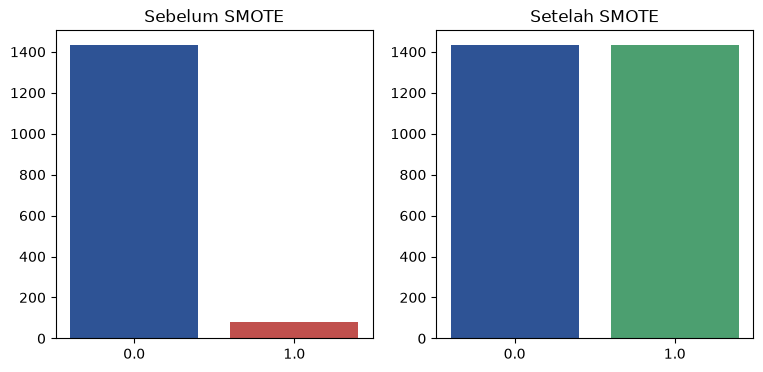

In [7]:
import matplotlib.pyplot as plt
before = y_train.value_counts()
after = pd.Series(y_train_sm).value_counts()
fig, axes = plt.subplots(1, 2, figsize=(9,4))
axes[0].bar(before.index.astype(str),before.values, color=["#2E5395","#C0504D"])
axes[0].set_title("Sebelum SMOTE")
axes[1].bar(after.index.astype(str),after.values, color=["#2E5395","#4C9F70"])
axes[1].set_title("Setelah SMOTE")
plt.show()

**Penjelasan outputnya:**

- Grafik kiri ("Sebelum SMOTE"): batang kelas 0 setinggi **1433**, batang kelas 1 cuma **82**, timpang sekali.
- Grafik kanan ("Setelah SMOTE"): kedua batang sama tinggi (**1433 vs 1433**). SMOTE mengisi kelas minoritas dengan sampel sintetis sampai seimbang.

### 3.9.1 Interpretasi (Modul Bab 3)

Model yang dilatih dengan data hasil SMOTE umumnya menunjukkan F1-Score yang jauh lebih tinggi dibandingkan model baseline, meskipun akurasi keduanya mungkin tidak jauh berbeda (atau bahkan akurasi baseline sedikit lebih tinggi karena "curang" memprediksi kelas mayoritas). Hal ini menegaskan bahwa akurasi bukan metrik yang tepat untuk kasus data tidak seimbang.

## Latihan Praktikum (Modul Bab 3, bagian 3.10)

### Latihan 1 - Perbandingan Strategi Imputasi

**Soal (modul 3.10):** bandingkan mean imputation vs KNN Imputer pada data sintetis di atas; latih LogisticRegression untuk tiap strategi; bandingkan skor F1.

In [8]:
from sklearn.impute import SimpleImputer
print(f"{'strategi imputasi':>18} | {'akurasi':>8} | {'F1':>7}")
print("-" * 41)
for nama, imp in [("Mean Imputation", SimpleImputer(strategy="mean")),
                  ("KNN Imputer (k=5)", KNNImputer(n_neighbors=5))]:
    df_lat = df_missing.copy()
    df_lat[fitur_cols] = imp.fit_transform(df_missing[fitur_cols])
    df_lat = df_lat.dropna(subset=["target"])
    Xl, yl = df_lat[fitur_cols], df_lat["target"].astype(int)
    Xtr, Xte, ytr, yte = train_test_split(Xl, yl, test_size=0.2,
        stratify=yl, random_state=42)
    m_lat = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    yp = m_lat.predict(Xte)
    print(f"{nama:>18} | {accuracy_score(yte, yp):>8.3f} | {f1_score(yte, yp):>7.3f}")

 strategi imputasi |  akurasi |      F1
-----------------------------------------
   Mean Imputation |    0.950 |   0.296
 KNN Imputer (k=5) |    0.953 |   0.308


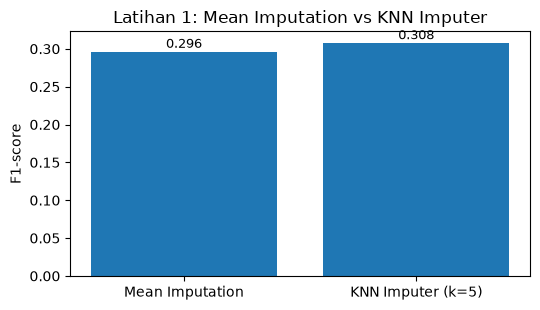

In [9]:
# Grafik Latihan 1: perbandingan F1 mean imputation vs KNN Imputer
hasil_imp = {}
for nama, imp in [("Mean Imputation", SimpleImputer(strategy="mean")),
                  ("KNN Imputer (k=5)", KNNImputer(n_neighbors=5))]:
    df_lat = df_missing.copy()
    df_lat[fitur_cols] = imp.fit_transform(df_missing[fitur_cols])
    df_lat = df_lat.dropna(subset=["target"])
    Xl, yl = df_lat[fitur_cols], df_lat["target"].astype(int)
    Xtr, Xte, ytr, yte = train_test_split(Xl, yl, test_size=0.2,
        stratify=yl, random_state=42)
    m_lat = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    hasil_imp[nama] = f1_score(yte, m_lat.predict(Xte))
plt.figure(figsize=(5.5, 3.2))
plt.bar(hasil_imp.keys(), hasil_imp.values())
plt.ylabel("F1-score")
plt.title("Latihan 1: Mean Imputation vs KNN Imputer")
for i, v in enumerate(hasil_imp.values()):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Jawaban Latihan 1:** KNN Imputer (F1 0,308) sedikit mengungguli mean imputation (F1 0,296). Selisihnya kecil, tapi imputasi berbasis tetangga tetap lebih baik karena memanfaatkan pola antar-fitur, bukan sekadar rata-rata kolom.

### Latihan 2 (Praktikum 3.7) - Efektivitas Penanganan Imbalanced Data

**Soal (modul 3.10):** terapkan `RandomUnderSampler` dan `LogisticRegression(class_weight="balanced")`; bandingkan F1-Score keempat pendekatan (baseline, SMOTE, undersampling, class_weight); tulis kesimpulan pendekatan mana yang paling efektif.

In [10]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_rus,y_train_rus = rus.fit_resample(X_train,y_train)
model_rus = LogisticRegression(max_iter=1000).fit(X_train_rus, y_train_rus)
model_cw = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train,y_train)
# Bandingkan F1-Score keempat pendekatan: baseline, SMOTE, undersampling, class_weight
print(f"{'pendekatan':>14} | {'akurasi':>8} | {'F1':>7}")
print("-" * 37)
for nama, model in [("Baseline", model_base), ("SMOTE", model_smote),
                    ("Undersampling", model_rus), ("class_weight", model_cw)]:
    yp = model.predict(X_test)
    print(f"{nama:>14} | {accuracy_score(y_test, yp):>8.3f} | {f1_score(y_test, yp):>7.3f}")

    pendekatan |  akurasi |      F1
-------------------------------------
      Baseline |    0.953 |   0.308
         SMOTE |    0.836 |   0.367
 Undersampling |    0.802 |   0.336
  class_weight |    0.821 |   0.346


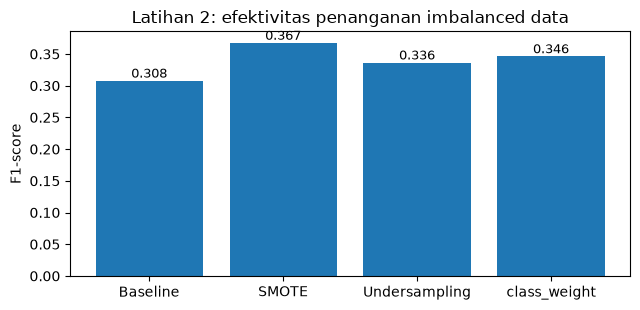

In [11]:
# Grafik Latihan 2: perbandingan F1 keempat pendekatan imbalance
hasil_imb = {}
for nama, model in [("Baseline", model_base), ("SMOTE", model_smote),
                    ("Undersampling", model_rus), ("class_weight", model_cw)]:
    hasil_imb[nama] = f1_score(y_test, model.predict(X_test))
plt.figure(figsize=(6.5, 3.2))
bars = plt.bar(hasil_imb.keys(), hasil_imb.values())
plt.ylabel("F1-score")
plt.title("Latihan 2: efektivitas penanganan imbalanced data")
for b, v in zip(bars, hasil_imb.values()):
    plt.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
             ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Kesimpulan Latihan 2:** SMOTE paling efektif untuk kasus ini dengan F1 tertinggi 0,367, disusul class_weight (0,346), undersampling (0,336), dan baseline terakhir (0,308). SMOTE menang karena menambah informasi kelas minoritas lewat sampel sintetis tanpa membuang data mayoritas, sedangkan undersampling kehilangan banyak data latih sehingga performanya turun.

## Percobaan Mandiri

Bagian ini berisi percobaan saya sendiri di luar modul, semuanya memakai data sintetis yang sama supaya hasilnya bisa dibandingkan langsung dengan praktikum di atas.

### Percobaan Mandiri 1 - Pengaruh `contamination` pada IsolationForest

Parameter `contamination` adalah tebakan proporsi outlier. Saya coba tiga nilai, buang outlier yang terdeteksi, lalu latih ulang model baseline untuk melihat efeknya ke F1.

In [12]:
print(f"{'contamination':>13} | {'outlier dibuang':>14} | {'F1 (setelah buang)':>18}")
print("-" * 51)
for c in [0.01, 0.02, 0.05]:
    iso_pm = IsolationForest(contamination=c, random_state=42)
    label_pm = iso_pm.fit_predict(df_imputed[fitur_cols])
    n_out = int((label_pm == -1).sum())
    df_pm = df_imputed[label_pm != -1].dropna(subset=["target"]).copy()
    df_pm["target"] = df_pm["target"].astype(int)
    Xtr, Xte, ytr, yte = train_test_split(df_pm[fitur_cols], df_pm["target"],
        test_size=0.2, stratify=df_pm["target"], random_state=42)
    m_pm = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    print(f"{c:>13} | {n_out:>14} | {f1_score(yte, m_pm.predict(Xte)):>18.3f}")

contamination | outlier dibuang | F1 (setelah buang)
---------------------------------------------------


         0.01 |             19 |              0.519


         0.02 |             38 |              0.273


         0.05 |             95 |              0.200


**Kesimpulan:** menaikkan contamination membuat semakin banyak baris dibuang (19, 38, 95) dan F1 justru turun dari 0,519 ke 0,200, jadi outlier tidak boleh dibuang terlalu agresif karena ikut membuang informasi penting.

### Percobaan Mandiri 2 - SMOTE dengan `k_neighbors` 5 vs 3

SMOTE membuat sampel sintetis dari interpolasi `k_neighbors` tetangga terdekat. Saya bandingkan nilai default (5) dengan 3.

In [13]:
print(f"{'k_neighbors':>11} | {'F1 (SMOTE)':>11}")
print("-" * 27)
for k in [5, 3]:
    sm_pm = SMOTE(random_state=42, k_neighbors=k)
    Xsm_pm, ysm_pm = sm_pm.fit_resample(X_train, y_train)
    m_pm = LogisticRegression(max_iter=1000).fit(Xsm_pm, ysm_pm)
    print(f"{k:>11} | {f1_score(y_test, m_pm.predict(X_test)):>11.3f}")

k_neighbors |  F1 (SMOTE)
---------------------------
          5 |       0.367
          3 |       0.340


**Kesimpulan:** k_neighbors=5 memberi F1 sedikit lebih tinggi (0,367 vs 0,340), jadi sampel sintetis dari tetangga yang lebih banyak menghasilkan sebaran kelas minoritas yang lebih halus.

### Percobaan Mandiri 3 - Tanpa vs Dengan Buang Outlier

Saya bandingkan model baseline dari Praktikum 3.4 (outlier hanya ditandai, tidak dibuang) dengan model yang dilatih setelah 40 baris outlier dibuang.

In [14]:
# tanpa buang outlier: pakai model_base dari Praktikum 3.4
f1_tanpa = f1_score(y_test, model_base.predict(X_test))
# dengan buang outlier: drop baris is_outlier == -1, lalu latih ulang
df_no_out = df_imputed[df_imputed["is_outlier"] != -1].dropna(subset=["target"]).copy()
df_no_out["target"] = df_no_out["target"].astype(int)
Xtr, Xte, ytr, yte = train_test_split(df_no_out[fitur_cols], df_no_out["target"],
    test_size=0.2, stratify=df_no_out["target"], random_state=42)
m_no_out = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
f1_dengan = f1_score(yte, m_no_out.predict(Xte))
print(f"F1 tanpa buang outlier : {f1_tanpa:.3f}")
print(f"F1 dengan buang outlier: {f1_dengan:.3f}")

F1 tanpa buang outlier : 0.308
F1 dengan buang outlier: 0.417


**Kesimpulan:** membuang 40 outlier sebelum training menaikkan F1 dari 0,308 ke 0,417, jadi data yang lebih bersih membantu model mengenali kelas minoritas, walau skornya tetap di bawah model SMOTE.

## Kesimpulan Bab 3

1. **Data kotor itu wajar, penanganannya bertahap.** Missing value pada fitur bisa diisi KNN Imputer yang memanfaatkan pola tetangga terdekat, sedangkan baris yang labelnya hilang tidak bisa diimputasi dan harus dibuang.
2. **Outlier perlu dideteksi, tapi jangan dibuang sembarangan.** Isolation Forest menandai 40 baris sebagai outlier dan membuangnya menaikkan F1, tapi contamination yang terlalu besar malah menurunkan performa.
3. **Akurasi menipu pada data tidak seimbang.** Baseline mencapai akurasi 0,953 tapi F1 cuma 0,308 karena gagal mengenali kelas minoritas.
4. **SMOTE paling efektif untuk kasus ini.** F1 naik ke 0,367, mengalahkan undersampling (0,336) dan class_weight (0,346), karena menambah informasi kelas minoritas tanpa membuang data.
5. **Detail kecil tetap berpengaruh.** KNN Imputer sedikit mengungguli mean imputation (F1 0,308 vs 0,296), dan SMOTE dengan k_neighbors=5 sedikit lebih baik dari k=3.